# Experiment: CyEmbed Batch 4 Unt/Tr 6 Dosages Analysis

Objective:
- Analyze sweep outputs and inspect archetypes/embeddings on Batch 4 Unt/Tr 6-dosage data.
- Allow manual override of the best setting.
- Compare mean archetype weights and embedding dimensions by condition, sample, and other metadata columns.

In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display



def _find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    for candidate in [resolved, *resolved.parents]:
        if (candidate / 'CyEmbed').exists():
            return candidate
    return resolved


PROJECT_ROOT_BOOTSTRAP = _find_project_root(Path.cwd())
if str(PROJECT_ROOT_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_BOOTSTRAP))

from CyEmbed.analysis import (
    archetype_marker_rankings,
    cosine_similarity_matrix,
    load_run_outputs,
    nearest_neighbors_from_similarity,
    pca_projection,
    per_marker_reconstruction_stats,
    residual_summary,
    summarize_by_group,
    umap_projection,
)
from CyEmbed.plotting import plot_clustermap, plot_embedding_scatter, plot_matrix_heatmap

pd.set_option('display.max_columns', 200)
sns.set_context('notebook')


In [2]:
def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    for candidate in [resolved, *resolved.parents]:
        if (candidate / 'CyEmbed').exists():
            return candidate
    return resolved


def make_unique_ids(values: list[str] | pd.Series) -> list[str]:
    counts: dict[str, int] = {}
    out: list[str] = []
    for idx, value in enumerate(values):
        base = str(value).strip() if pd.notna(value) else ''
        if not base:
            base = f'row_{idx}'
        seen = counts.get(base, 0)
        out.append(base if seen == 0 else f'{base}__dup{seen}')
        counts[base] = seen + 1
    return out


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = Path('/Users/ronguy/Dropbox/WIS-CIMA colab - Analysis/summarized data/forGuy/Batch4_Unt_Tr_6dosages_all_samples_GFPpos_GFPneg.csv')
SWEEP_ROOT = PROJECT_ROOT / 'outputs' / 'batch4_unt_tr_6dosages_gfppos_only_sweep'
ANALYSIS_OUTDIR = PROJECT_ROOT / 'outputs' / 'batch4_unt_tr_6dosages_gfppos_only_analysis'
ANALYSIS_OUTDIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ANALYSIS_OUTDIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_CFG = {
    'ranking_metric': 'val_recon',
    'ranking_ascending': True,
    'selected_k': 7,  # set to int (e.g., 4 or 5) to select best run within that K
    'k_selection_mode': 'smallest_within_relative_tol',  # used only when selected_k is None
    'k_selection_relative_tol': 0.02,
    'k_selection_absolute_tol': 0.01,
    'dead_archetype_penalty_per_dead': 0.05,  # multiplicative penalty applied per dead archetype during run/K selection
    'override_run_dir': None,      # absolute/relative run dir path
    'override_run_id': None,       # exact run_id from sweep summary
    'override_rank_index': 0,      # ignored if override_run_dir or override_run_id is set
    'cell_id_col': 'cell_id',
    'sample_col': 'sample_name',
    'condition_col': 'condition',
    'condition_binary_col': 'condition_binary',
    'gfp_group_col': 'GFP_group',
    'gfp_positive_only': True,
    'gfp_positive_values': ['GFPpos', 'GFP+', 'pos', 'positive'],
    'metadata_columns': ['sample_name', 'condition', 'condition_binary', 'sample_folder', 'GFP_group', 'source_file', 'batch'],
    'focus_group_columns': ['sample_name', 'condition_binary'],
    'only_focus_group_columns': True,
    'max_groups_per_column': 80,
    'heatmap_max_groups': 30,
}

print(f'PROJECT_ROOT:  {PROJECT_ROOT}')
print(f'SWEEP_ROOT:    {SWEEP_ROOT}')
print(f'ANALYSIS_OUT:  {ANALYSIS_OUTDIR}')


PROJECT_ROOT:  /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed
SWEEP_ROOT:    /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep
ANALYSIS_OUT:  /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis


In [3]:
def _safe_float(value, default=np.nan):
    try:
        if value is None or (isinstance(value, str) and not value.strip()):
            return default
        return float(value)
    except Exception:
        return default


def _safe_int(value, default=None):
    try:
        if value is None or (isinstance(value, str) and not value.strip()):
            return default
        return int(value)
    except Exception:
        return default


def _format_hidden_dims(value) -> str | None:
    if value is None:
        return None
    if isinstance(value, (list, tuple)):
        return '-'.join(str(int(v)) if isinstance(v, (int, np.integer, float)) and float(v).is_integer() else str(v) for v in value)
    return str(value)


def discover_run_summaries(sweep_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_dirs = sorted([p for p in sweep_root.glob('run_*') if p.is_dir()])
    rows: list[dict] = []
    skipped_rows: list[dict] = []

    for run_dir in run_dirs:
        config_path = run_dir / 'config.json'
        summary_path = run_dir / 'summary_metrics.json'
        history_path = run_dir / 'history.csv'

        missing = [p.name for p in [config_path, summary_path] if not p.exists()]
        if missing:
            skipped_rows.append({'run_dir': str(run_dir), 'reason': f"missing required files: {', '.join(missing)}"})
            continue

        try:
            config = json.loads(config_path.read_text())
            summary = json.loads(summary_path.read_text())
            history_df = pd.read_csv(history_path) if history_path.exists() else None

            train_metrics = summary.get('train', {}) if isinstance(summary.get('train', {}), dict) else {}
            val_metrics = summary.get('val', {}) if isinstance(summary.get('val', {}), dict) else {}

            if history_df is not None and not history_df.empty:
                final_hist = history_df.iloc[-1]
                val_recon = _safe_float(val_metrics.get('recon_mse', final_hist.get('val_recon', np.nan)))
                train_loss = _safe_float(final_hist.get('loss', train_metrics.get('recon_mae', np.nan)))
                final_kl_w = _safe_float(final_hist.get('kl_w', np.nan))
                final_kl_r = _safe_float(final_hist.get('kl_r', np.nan))
                observed_epochs = _safe_int(history_df['epoch'].max(), len(history_df))
                if observed_epochs is None:
                    observed_epochs = len(history_df)
            else:
                val_recon = _safe_float(val_metrics.get('recon_mse', np.nan))
                train_loss = _safe_float(train_metrics.get('recon_mae', np.nan))
                final_kl_w = np.nan
                final_kl_r = np.nan
                observed_epochs = None

            configured_epochs = _safe_int(config.get('epochs'), None)
            best_epoch = _safe_int(summary.get('best_epoch'), None)
            stopped_early = None
            if configured_epochs is not None and observed_epochs is not None:
                stopped_early = bool(observed_epochs < configured_epochs)

            row = {
                'run_id': str(summary.get('run_id', run_dir.name)),
                'run_dir': str(run_dir.resolve()),
                'model_type': config.get('model_type', summary.get('model_type')),
                'decoder_type': config.get('decoder_type', summary.get('decoder_type')),
                'use_residual_latent': bool(config.get('use_residual_latent', summary.get('use_residual_latent', False))),
                'beta_w': _safe_float(config.get('beta_w', np.nan)),
                'beta_r': _safe_float(config.get('beta_r', np.nan)),
                'residual_dim': _safe_int(config.get('residual_dim'), None),
                'K': _safe_int(config.get('K'), None),
                'd': _safe_int(config.get('d'), None),
                'hidden_dims': _format_hidden_dims(config.get('hidden_dims')),
                'lr': _safe_float(config.get('lr', np.nan)),
                'batch_size': _safe_int(config.get('batch_size'), None),
                'recon_loss_type': config.get('recon_loss_type'),
                'lambda_entropy': _safe_float(config.get('lambda_entropy', np.nan)),
                'lambda_sep': _safe_float(config.get('lambda_sep', np.nan)),
                'lambda_balance': _safe_float(config.get('lambda_balance', np.nan)),
                'tau': _safe_float(config.get('tau', np.nan)),
                'patience': _safe_int(config.get('patience'), None),
                'best_epoch': best_epoch,
                'stopped_early': stopped_early,
                'val_recon': val_recon,
                'train_loss': train_loss,
                'mean_marker_corr_val': _safe_float(val_metrics.get('mean_marker_corr', np.nan)),
                'mean_entropy_val': _safe_float(val_metrics.get('mean_weight_entropy', np.nan)),
                'usage_std_val': _safe_float(val_metrics.get('usage_std', np.nan)),
                'dead_archetypes_val': _safe_int(val_metrics.get('dead_archetypes_lt_1pct'), None),
                'dominant_frac_gt_0_5_val': _safe_float(val_metrics.get('dominant_frac_gt_0_5', np.nan)),
                'dominant_frac_gt_0_8_val': _safe_float(val_metrics.get('dominant_frac_gt_0_8', np.nan)),
                'final_kl_w': final_kl_w,
                'final_kl_r': final_kl_r,
            }
            rows.append(row)
        except Exception as exc:
            skipped_rows.append({'run_dir': str(run_dir), 'reason': f'{type(exc).__name__}: {exc}'})

    return pd.DataFrame(rows), pd.DataFrame(skipped_rows)


def add_selection_score(summary_df: pd.DataFrame, metric: str, ascending: bool, cfg: dict) -> pd.DataFrame:
    if metric not in summary_df.columns:
        raise ValueError(f"Selection metric '{metric}' not found in discovered run summaries.")

    work_df = summary_df.copy()
    if 'dead_archetypes_val' not in work_df.columns:
        work_df['dead_archetypes_val'] = 0
    work_df['dead_archetypes_val'] = pd.to_numeric(work_df['dead_archetypes_val'], errors='coerce').fillna(0).astype(int)

    penalty_per_dead = float(cfg.get('dead_archetype_penalty_per_dead', 0.05))
    work_df['dead_archetype_penalty_per_dead'] = penalty_per_dead
    work_df['dead_archetype_penalty'] = work_df['dead_archetypes_val'] * penalty_per_dead
    work_df['dead_archetype_penalty_multiplier'] = 1.0 + work_df['dead_archetype_penalty']

    metric_values = pd.to_numeric(work_df[metric], errors='coerce')
    if ascending:
        work_df['selection_score'] = metric_values * work_df['dead_archetype_penalty_multiplier']
    else:
        work_df['selection_score'] = metric_values / work_df['dead_archetype_penalty_multiplier']
    return work_df


def build_k_selection_summary(summary_ranked_df: pd.DataFrame, metric: str, ascending: bool, cfg: dict) -> pd.DataFrame:
    if 'K' not in summary_ranked_df.columns:
        raise ValueError("Column 'K' not found in discovered run summaries.")

    work_df = summary_ranked_df.dropna(subset=['K', metric]).copy()
    work_df['K'] = work_df['K'].astype(int)
    work_df = add_selection_score(work_df, metric=metric, ascending=ascending, cfg=cfg)
    per_k_best_df = (
        work_df.sort_values(['selection_score', metric, 'K'], ascending=[ascending, ascending, True])
        .groupby('K', as_index=False)
        .first()
        .sort_values('K')
        .reset_index(drop=True)
    )

    best_metric = float(per_k_best_df[metric].min() if ascending else per_k_best_df[metric].max())
    metric_denom = max(abs(best_metric), 1e-12)
    if ascending:
        per_k_best_df['metric_gap_from_best'] = per_k_best_df[metric] - best_metric
    else:
        per_k_best_df['metric_gap_from_best'] = best_metric - per_k_best_df[metric]
    per_k_best_df['relative_gap_from_best'] = per_k_best_df['metric_gap_from_best'] / metric_denom

    best_selection_score = float(per_k_best_df['selection_score'].min() if ascending else per_k_best_df['selection_score'].max())
    selection_denom = max(abs(best_selection_score), 1e-12)
    if ascending:
        per_k_best_df['selection_score_gap_from_best'] = per_k_best_df['selection_score'] - best_selection_score
    else:
        per_k_best_df['selection_score_gap_from_best'] = best_selection_score - per_k_best_df['selection_score']
    per_k_best_df['selection_relative_gap_from_best'] = per_k_best_df['selection_score_gap_from_best'] / selection_denom
    return per_k_best_df


def choose_auto_k(per_k_best_df: pd.DataFrame, metric: str, ascending: bool, cfg: dict) -> tuple[int, str]:
    mode = str(cfg.get('k_selection_mode', 'smallest_within_relative_tol')).lower()
    penalty_per_dead = float(cfg.get('dead_archetype_penalty_per_dead', 0.05))
    score_col = 'selection_score' if 'selection_score' in per_k_best_df.columns else metric
    best_score = float(per_k_best_df[score_col].min() if ascending else per_k_best_df[score_col].max())

    if mode == 'best_metric':
        chosen_row = per_k_best_df.sort_values([score_col, metric, 'K'], ascending=[ascending, ascending, True]).iloc[0]
        reason = (
            f"Selected best penalized score directly; best {score_col}={best_score:.6g} "
            f"with dead-archetype penalty {penalty_per_dead:.3g} per dead archetype."
        )
        return int(chosen_row['K']), reason

    if mode == 'smallest_within_relative_tol':
        rel_tol = float(cfg.get('k_selection_relative_tol', 0.02))
        if 'selection_relative_gap_from_best' in per_k_best_df.columns:
            mask = per_k_best_df['selection_relative_gap_from_best'] <= rel_tol
        else:
            threshold = best_score * (1.0 + rel_tol) if ascending else best_score * (1.0 - rel_tol)
            mask = per_k_best_df[score_col] <= threshold if ascending else per_k_best_df[score_col] >= threshold
        reason = (
            f"Selected smallest K within {rel_tol:.2%} of best penalized {score_col}={best_score:.6g}; "
            f"dead-archetype penalty={penalty_per_dead:.3g} per dead archetype."
        )
    elif mode == 'smallest_within_absolute_tol':
        abs_tol = float(cfg.get('k_selection_absolute_tol', 0.01))
        threshold = best_score + abs_tol if ascending else best_score - abs_tol
        mask = per_k_best_df[score_col] <= threshold if ascending else per_k_best_df[score_col] >= threshold
        reason = (
            f"Selected smallest K within absolute tolerance {abs_tol:.6g} of best penalized {score_col}={best_score:.6g}; "
            f"dead-archetype penalty={penalty_per_dead:.3g} per dead archetype."
        )
    else:
        raise ValueError(
            "ANALYSIS_CFG['k_selection_mode'] must be one of {'best_metric', 'smallest_within_relative_tol', 'smallest_within_absolute_tol'}."
        )

    candidates = per_k_best_df.loc[mask].copy()
    if candidates.empty:
        candidates = per_k_best_df.copy()
        reason += ' No candidates met the tolerance, so fell back to smallest available K.'
    chosen_row = candidates.sort_values('K').iloc[0]
    return int(chosen_row['K']), reason


discovered_df, skipped_runs_df = discover_run_summaries(SWEEP_ROOT)
if discovered_df.empty:
    raise FileNotFoundError(f'No valid run_* directories with config.json and summary_metrics.json were found under: {SWEEP_ROOT}')

metric = ANALYSIS_CFG['ranking_metric']
if metric not in discovered_df.columns:
    raise ValueError(f"Ranking metric '{metric}' not found in discovered run summaries.")

ascending = bool(ANALYSIS_CFG['ranking_ascending'])
scored_df = add_selection_score(discovered_df, metric=metric, ascending=ascending, cfg=ANALYSIS_CFG)
summary_all_df = scored_df.sort_values(['selection_score', metric, 'K'], ascending=[ascending, ascending, True]).reset_index(drop=True)
print(f'Discovered {len(summary_all_df)} valid runs under {SWEEP_ROOT}.')
print(
    'Applied dead-archetype penalty in run ranking: '
    f"{float(ANALYSIS_CFG.get('dead_archetype_penalty_per_dead', 0.05)):.3g} per dead archetype."
)
if not skipped_runs_df.empty:
    skipped_path = ANALYSIS_OUTDIR / 'run_discovery_skipped.csv'
    skipped_runs_df.to_csv(skipped_path, index=False)
    print(f'Skipped {len(skipped_runs_df)} run directories with missing/incomplete metadata. Details: {skipped_path}')

selection_summary_df = None
selection_summary_path = ANALYSIS_OUTDIR / 'k_selection_summary.csv'
if 'K' in summary_all_df.columns:
    selection_summary_df = build_k_selection_summary(summary_all_df, metric=metric, ascending=ascending, cfg=ANALYSIS_CFG)
    selection_summary_df.to_csv(selection_summary_path, index=False)
    print(f'Saved K-selection summary: {selection_summary_path}')
    display(selection_summary_df)

selected_k = ANALYSIS_CFG.get('selected_k', None)
if selected_k is not None:
    if 'K' not in summary_all_df.columns:
        raise ValueError("selected_k is set, but column 'K' was not found in discovered run summaries.")
    selected_k = int(selected_k)
    summary_df = summary_all_df.loc[summary_all_df['K'].astype(int) == selected_k].copy()
    if summary_df.empty:
        available_ks = sorted(summary_all_df['K'].dropna().astype(int).unique().tolist())
        raise ValueError(f'No runs found for selected_k={selected_k}. Available K values: {available_ks}')
    print(f'Filtering run selection to K={selected_k}. Matching runs: {len(summary_df)}')
else:
    k_selection_mode = str(ANALYSIS_CFG.get('k_selection_mode', 'smallest_within_relative_tol')).lower()
    if k_selection_mode == 'best_metric' or selection_summary_df is None:
        summary_df = summary_all_df.copy()
        print('Using global penalized run ranking without automatic K complexity tolerance.')
    else:
        selected_k, selection_reason = choose_auto_k(selection_summary_df, metric=metric, ascending=ascending, cfg=ANALYSIS_CFG)
        print(f'Auto-selected K={selected_k}. {selection_reason}')
        summary_df = summary_all_df.loc[summary_all_df['K'].astype(int) == selected_k].copy()

summary_df = summary_df.sort_values(['selection_score', metric, 'K'], ascending=[ascending, ascending, True]).reset_index(drop=True)

snapshot_all_path = ANALYSIS_OUTDIR / 'available_runs_snapshot_all.csv'
snapshot_path = ANALYSIS_OUTDIR / 'available_runs_snapshot.csv'
summary_all_df.to_csv(snapshot_all_path, index=False)
summary_df.to_csv(snapshot_path, index=False)
print(f'Saved full discovered run snapshot: {snapshot_all_path}')
print(f'Saved active discovered run snapshot: {snapshot_path}')
display(summary_df.head(20))

selected_row = None
if ANALYSIS_CFG['override_run_dir'] is not None:
    selected_run_dir = Path(ANALYSIS_CFG['override_run_dir']).expanduser().resolve()
    matches = summary_all_df.loc[summary_all_df['run_dir'].astype(str) == str(selected_run_dir)]
    if len(matches):
        selected_row = matches.iloc[0]
elif ANALYSIS_CFG['override_run_id'] is not None:
    run_matches = summary_all_df.loc[summary_all_df['run_id'] == ANALYSIS_CFG['override_run_id']]
    if run_matches.empty:
        raise ValueError(f"override_run_id '{ANALYSIS_CFG['override_run_id']}' not found among discovered runs.")
    selected_row = run_matches.iloc[0]
    if selected_k is not None and pd.notna(selected_row.get('K')) and int(selected_row['K']) != int(selected_k):
        print(f"Note: override_run_id uses K={int(selected_row['K'])}, while selected_k={selected_k}.")
    selected_run_dir = Path(selected_row['run_dir'])
else:
    rank_index = int(ANALYSIS_CFG['override_rank_index'])
    if rank_index < 0 or rank_index >= len(summary_df):
        raise IndexError(f'override_rank_index out of range: {rank_index}')
    selected_row = summary_df.iloc[rank_index]
    selected_run_dir = Path(selected_row['run_dir'])

print(f'Selected run dir: {selected_run_dir}')
if selected_row is not None:
    print('Selected run summary row:')
    display(selected_row.to_frame().T)


Filtering run selection to K=7. Matching runs: 4
Saved full ranked run snapshot: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/available_runs_snapshot_all.csv
Saved active ranked run snapshot: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/available_runs_snapshot.csv


,run_id,run_dir,model_type,decoder_type,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_0346a13f48,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0010,4096,mse,0.000,0.02,0.0,0.8,25,379,True,0.403572,0.419171,0.759629,1.802439,0.030305,0,0.000844,0.0,22.714696,0.0
1,run_probabilistic_cb76a73638,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0010,4096,mse,0.003,0.02,0.0,0.8,25,391,True,0.403689,0.424071,0.761091,1.788291,0.034643,0,0.000774,0.0,22.439897,0.0
2,run_probabilistic_6c060e7e84,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0005,4096,mse,0.003,0.02,0.0,0.8,25,657,True,0.403717,0.424113,0.760816,1.788394,0.035489,0,0.000492,0.0,22.496164,0.0
3,run_probabilistic_ec95208321,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.0005,4096,mse,0.000,0.02,0.0,0.8,25,557,True,0.403833,0.419604,0.759293,1.809523,0.021029,0,0.000703,0.0,22.700294,0.0


Selected run dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_sweep/run_probabilistic_0346a13f48
Selected run summary row:


,run_id,run_dir,model_type,decoder_type,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_0346a13f48,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,False,0.0005,0.0,8,7,8,256-128,0.001,4096,mse,0.0,0.02,0.0,0.8,25,379,True,0.403572,0.419171,0.759629,1.802439,0.030305,0,0.000844,0.0,22.714696,0.0


Cells:   71,100
Markers: 34
Archetypes (K): 7
Loaded run_id: run_probabilistic_0346a13f48


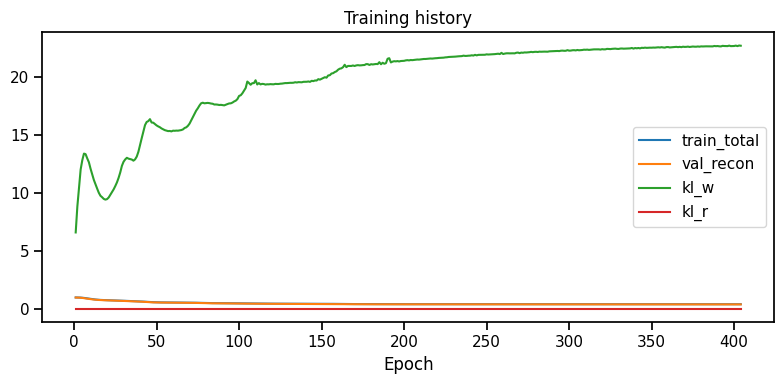

In [4]:
run = load_run_outputs(selected_run_dir)

history_df = run['history']
marker_names = run['marker_names']
cell_ids = np.asarray(run['cell_ids'], dtype=str)
X = run.get('X_observed', run.get('X'))
X_hat = run['X_hat']
A_hat = run.get('A_hat')
W = run.get('W_mean', run.get('W'))
U = run.get('mu_w', run.get('U'))
E = run.get('E')
Z = run.get('Z')

print(f'Cells:   {X.shape[0]:,}')
print(f'Markers: {X.shape[1]}')
print(f'Archetypes (K): {W.shape[1]}')
print(f'Loaded run_id: {run.get("summary_metrics", {}).get("run_id", "n/a")}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df['epoch'], history_df['loss'], label='train_total')
ax.plot(history_df['epoch'], history_df['val_recon'], label='val_recon')
if 'kl_w' in history_df.columns:
    ax.plot(history_df['epoch'], history_df['kl_w'], label='kl_w')
if 'kl_r' in history_df.columns:
    ax.plot(history_df['epoch'], history_df['kl_r'], label='kl_r')
ax.set_title('Training history')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/per_marker_reconstruction_stats.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/residual_marker_summary.csv


,marker,pearson_r,spearman_r,r2,mse,mae
0,Vimentin,0.912881,0.917985,0.833235,0.166766,0.313347
1,H3K4me2,0.909721,0.877958,0.827576,0.172426,0.324133
2,H3K36me3,0.906256,0.907132,0.821181,0.178821,0.328577
3,GAL4,0.904868,0.893519,0.818784,0.181215,0.342637
4,KRT5,0.898249,0.900373,0.806715,0.193287,0.340693
5,H3K27ac,0.862887,0.864481,0.744556,0.255446,0.387432
6,pRb,0.859647,0.829737,0.738969,0.261032,0.390624
7,H3K27me2,0.858167,0.784713,0.736388,0.263615,0.399558
8,Pan-KRT,0.856783,0.899979,0.733977,0.266026,0.342405
9,H3K4me3,0.855233,0.845427,0.731398,0.268606,0.403929


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/archetype_marker_loadings.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/archetype_marker_rankings.csv


,archetype,direction,rank,marker,value
0,0,positive,1,H3K36me3,8.631127
1,0,positive,2,KRT5,8.414565
2,0,positive,3,H3K9me2,5.889372
3,0,positive,4,H3K4me3,5.167457
4,0,positive,5,pRb,2.871334
5,0,positive,6,H3K4me1,2.283210
6,0,positive,7,EZH2,2.027399
7,0,positive,8,H3K4me2,1.460092
8,0,positive,9,H3K27me2,1.439999
9,0,positive,10,H3K36me2,1.141396


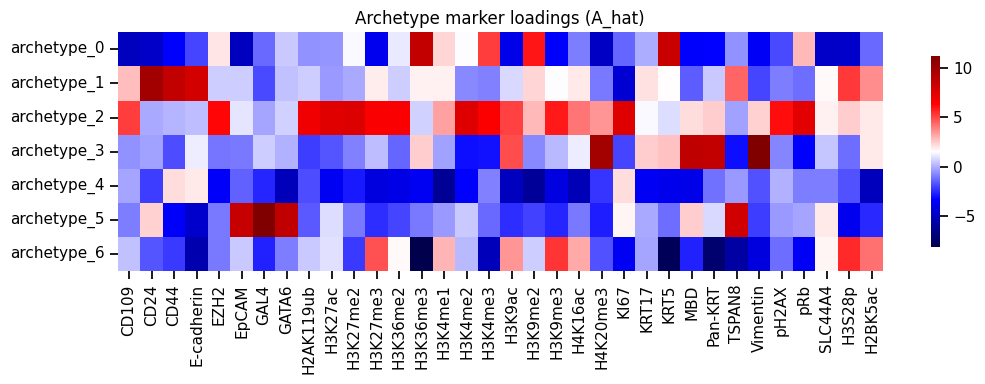

In [5]:
recon_df = per_marker_reconstruction_stats(X, X_hat, marker_names)
residual_df = residual_summary(X, X_hat, marker_names)

recon_path = ANALYSIS_OUTDIR / 'per_marker_reconstruction_stats.csv'
residual_path = ANALYSIS_OUTDIR / 'residual_marker_summary.csv'
recon_df.to_csv(recon_path, index=False)
residual_df.to_csv(residual_path, index=False)

print(f'Saved: {recon_path}')
print(f'Saved: {residual_path}')
display(recon_df.head(20))

if A_hat is not None:
    archetype_profile_df = pd.DataFrame(
        A_hat,
        index=[f'archetype_{i}' for i in range(A_hat.shape[0])],
        columns=marker_names,
    )
    archetype_profile_path = ANALYSIS_OUTDIR / 'archetype_marker_loadings.csv'
    archetype_profile_df.to_csv(archetype_profile_path)

    ranking_df = archetype_marker_rankings(A_hat, marker_names, top_n=15)
    ranking_path = ANALYSIS_OUTDIR / 'archetype_marker_rankings.csv'
    ranking_df.to_csv(ranking_path, index=False)

    print(f'Saved: {archetype_profile_path}')
    print(f'Saved: {ranking_path}')
    display(ranking_df.head(30))

    plot_matrix_heatmap(
        A_hat,
        row_labels=[f'archetype_{i}' for i in range(A_hat.shape[0])],
        col_labels=marker_names,
        title='Archetype marker loadings (A_hat)',
        cmap='seismic',
        figsize=(max(10, int(len(marker_names) * 0.35)), max(3, int(A_hat.shape[0] * 0.7))),
    )


In [6]:
recon_df

,marker,pearson_r,spearman_r,r2,mse,mae
0,Vimentin,0.912881,0.917985,0.833235,0.166766,0.313347
1,H3K4me2,0.909721,0.877958,0.827576,0.172426,0.324133
2,H3K36me3,0.906256,0.907132,0.821181,0.178821,0.328577
3,GAL4,0.904868,0.893519,0.818784,0.181215,0.342637
4,KRT5,0.898249,0.900373,0.806715,0.193287,0.340693
5,H3K27ac,0.862887,0.864481,0.744556,0.255446,0.387432
6,pRb,0.859647,0.829737,0.738969,0.261032,0.390624
7,H3K27me2,0.858167,0.784713,0.736388,0.263615,0.399558
8,Pan-KRT,0.856783,0.899979,0.733977,0.266026,0.342405
9,H3K4me3,0.855233,0.845427,0.731398,0.268606,0.403929


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/embedding_dim_mean_loadings.csv


,embedding_dim,mean_abs_marker_loading
0,embed_dim_0,0.973865
1,embed_dim_2,0.955479
2,embed_dim_3,0.952699
3,embed_dim_1,0.948744
4,embed_dim_6,0.906726
5,embed_dim_4,0.887263
6,embed_dim_5,0.852722
7,embed_dim_7,0.835556


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/embedding_dim_top_markers.csv


,embedding_dim,direction,rank,marker,loading
0,embed_dim_0,positive,1,KI67,1.342511
1,embed_dim_0,positive,2,EpCAM,0.958101
2,embed_dim_0,positive,3,GAL4,0.954872
3,embed_dim_0,positive,4,TSPAN8,0.738799
4,embed_dim_0,positive,5,pH2AX,0.175819
5,embed_dim_0,positive,6,pRb,0.114490
6,embed_dim_0,positive,7,SLC44A4,-0.063148
7,embed_dim_0,positive,8,GATA6,-0.082923
8,embed_dim_0,positive,9,H3K4me3,-0.108678
9,embed_dim_0,positive,10,CD109,-0.252302


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/archetype_embedding_coordinates_Z.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/cell_embedding_dim_mean_loadings.csv


,embedding_dim,mean_loading,mean_abs_loading,std_loading
2,u_dim_2,-0.212504,0.526672,0.642337
4,u_dim_4,0.357672,0.490339,0.484955
5,u_dim_5,-0.226354,0.471729,0.581882
1,u_dim_1,-0.131847,0.388712,0.549332
3,u_dim_3,0.062199,0.355961,0.494354
6,u_dim_6,0.014548,0.334048,0.482967
0,u_dim_0,0.131877,0.311237,0.405304


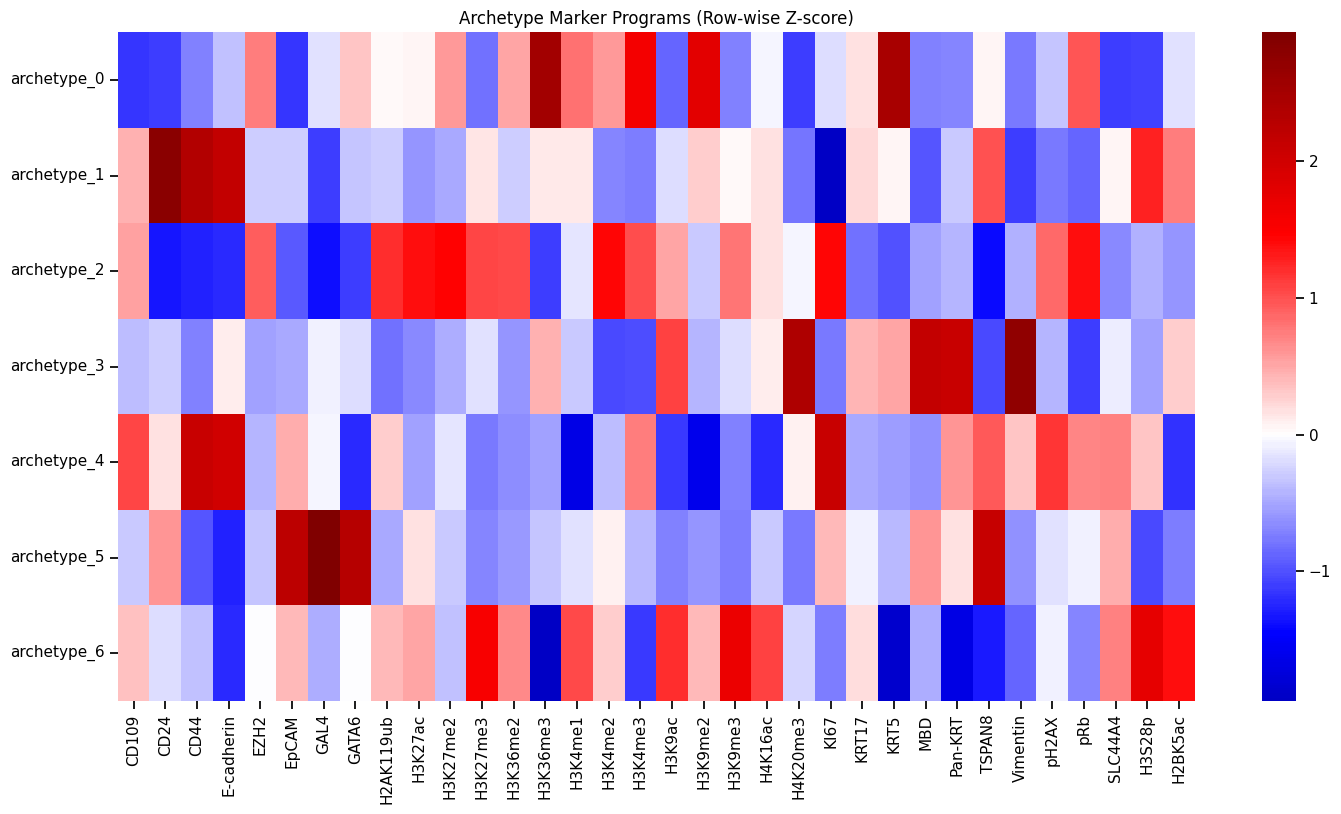

In [7]:
# Mean loadings by embedding dimension to help identify archetypes.
if E is not None:
    e_dim_cols = [f'embed_dim_{i}' for i in range(E.shape[1])]
    e_df = pd.DataFrame(E, index=marker_names, columns=e_dim_cols)

    mean_loading_df = (
        e_df.abs()
        .mean(axis=0)
        .rename('mean_abs_marker_loading')
        .reset_index()
        .rename(columns={'index': 'embedding_dim'})
        .sort_values('mean_abs_marker_loading', ascending=False)
        .reset_index(drop=True)
    )
    mean_loading_path = ANALYSIS_OUTDIR / 'embedding_dim_mean_loadings.csv'
    mean_loading_df.to_csv(mean_loading_path, index=False)
    print(f'Saved: {mean_loading_path}')
    display(mean_loading_df)

    top_rows = []
    top_n = 12
    for dim in e_dim_cols:
        dim_series = e_df[dim]
        top_pos = dim_series.sort_values(ascending=False).head(top_n)
        top_neg = dim_series.sort_values(ascending=True).head(top_n)
        for rank, (marker, value) in enumerate(top_pos.items(), start=1):
            top_rows.append({'embedding_dim': dim, 'direction': 'positive', 'rank': rank, 'marker': marker, 'loading': float(value)})
        for rank, (marker, value) in enumerate(top_neg.items(), start=1):
            top_rows.append({'embedding_dim': dim, 'direction': 'negative', 'rank': rank, 'marker': marker, 'loading': float(value)})

    top_marker_df = pd.DataFrame(top_rows)
    top_marker_path = ANALYSIS_OUTDIR / 'embedding_dim_top_markers.csv'
    top_marker_df.to_csv(top_marker_path, index=False)
    print(f'Saved: {top_marker_path}')
    display(top_marker_df.head(40))

if Z is not None:
    z_dim_cols = [f'embed_dim_{i}' for i in range(Z.shape[1])]
    z_df = pd.DataFrame(Z, index=[f'archetype_{i}' for i in range(Z.shape[0])], columns=z_dim_cols)
    z_path = ANALYSIS_OUTDIR / 'archetype_embedding_coordinates_Z.csv'
    z_df.to_csv(z_path)
    print(f'Saved: {z_path}')

if U is not None:
    u_cols = [f'u_dim_{i}' for i in range(U.shape[1])]
    u_df = pd.DataFrame(U, columns=u_cols)
    u_summary = pd.DataFrame({
        'embedding_dim': u_cols,
        'mean_loading': u_df.mean(axis=0).to_numpy(),
        'mean_abs_loading': u_df.abs().mean(axis=0).to_numpy(),
        'std_loading': u_df.std(axis=0).to_numpy(),
    }).sort_values('mean_abs_loading', ascending=False)
    u_summary_path = ANALYSIS_OUTDIR / 'cell_embedding_dim_mean_loadings.csv'
    u_summary.to_csv(u_summary_path, index=False)
    print(f'Saved: {u_summary_path}')
    display(u_summary.head(20))

if A_hat is not None:
    components_df = pd.DataFrame(
        A_hat,
        index=[f'archetype_{i}' for i in range(A_hat.shape[0])],
        columns=marker_names,
    )
    components_df.to_csv(ANALYSIS_OUTDIR / 'components_mean_matrix.csv')

    # Complementary structure visualization: row-wise standardized archetype programs.
    z_row = components_df.sub(components_df.mean(axis=1), axis=0)
    z_row = z_row.div(components_df.std(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    z_row.to_csv(ANALYSIS_OUTDIR / 'components_rowwise_zscore_matrix.csv')

    plt.figure(figsize=(min(20, 0.35 * len(marker_names) + 3), 0.9 * len(components_df) + 2))
    sns.heatmap(z_row, cmap='seismic', center=0)
    plt.title('Archetype Marker Programs (Row-wise Z-score)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'archetype_marker_programs_zscore.png', dpi=150)
    plt.show()


Saved aligned metadata: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/aligned_metadata_for_run.csv
Rows before GFP filter: 238,289 | Rows after GFP+ filter: 71,100

Group summary for condition_binary:


,condition_binary,archetype_0,archetype_1,archetype_2,archetype_3,archetype_4,archetype_5,archetype_6
0,Treated,0.180871,0.089248,0.126547,0.120018,0.196305,0.141989,0.145022
1,Untreated,0.145706,0.127902,0.117670,0.157062,0.211568,0.104243,0.135848



Group summary for sample_name:


,sample_name,archetype_0,archetype_1,archetype_2,archetype_3,archetype_4,archetype_5,archetype_6
0,A8,0.158623,0.107721,0.143159,0.156091,0.172914,0.124839,0.136652
1,A9,0.140218,0.136477,0.106840,0.157475,0.227991,0.095492,0.135507
2,B8,0.177448,0.090635,0.124641,0.113236,0.194715,0.155013,0.144312
3,B9,0.188719,0.086067,0.130915,0.135565,0.199952,0.112131,0.146651



Saved group output index: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/group_analysis_outputs.csv


,group_column,n_groups,mean_weights_path,dominant_fractions_path,mean_embedding_dims_path
0,condition_binary,2,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...
1,sample_name,4,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...


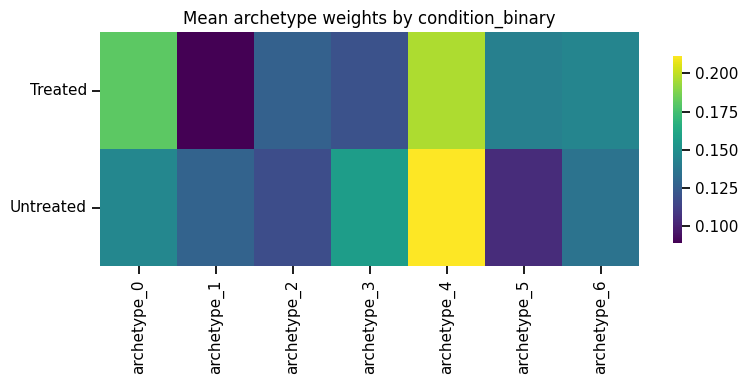

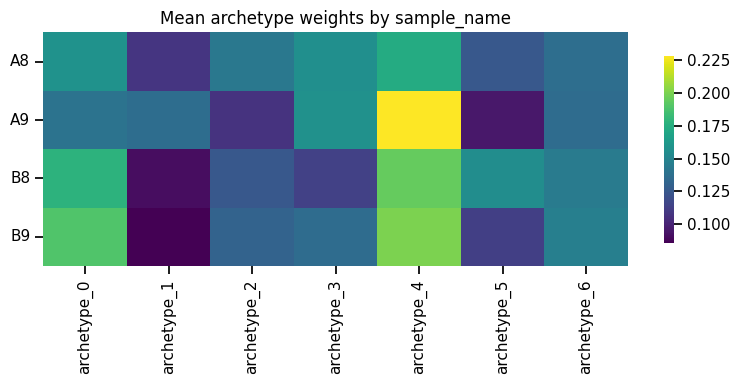

In [8]:
def canonicalize_value(value: object) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(value).lower())


def normalize_condition_label(value: object) -> str:
    text = str(value).strip()
    canon = canonicalize_value(text)
    if canon == '' or canon == 'nan':
        return 'Unknown'
    if canon in {'unt', 'untreated'} or canon.startswith('untreated') or canon.startswith('unt'):
        return 'Untreated'
    if canon in {'tr', 'treated'} or canon.startswith('treated') or canon.startswith('tr'):
        return 'Treated'
    return text


if not DATA_PATH.exists():
    raise FileNotFoundError(f'CSV not found: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
rows_before_gfp = int(raw_df.shape[0])

if ANALYSIS_CFG.get('gfp_positive_only', False):
    gfp_col = ANALYSIS_CFG.get('gfp_group_col', 'GFP_group')
    if gfp_col not in raw_df.columns:
        raise KeyError(f"GFP filter requested but column '{gfp_col}' not found in CSV.")
    gfp_targets = {canonicalize_value(v) for v in ANALYSIS_CFG.get('gfp_positive_values', ['GFPpos'])}
    gfp_mask = raw_df[gfp_col].map(lambda v: canonicalize_value(v) in gfp_targets)
    raw_df = raw_df.loc[gfp_mask].copy()

rows_after_gfp = int(raw_df.shape[0])
if rows_after_gfp == 0:
    raise ValueError('No rows remained after GFP+ filtering.')

if ANALYSIS_CFG['cell_id_col'] in raw_df.columns:
    base_ids = raw_df[ANALYSIS_CFG['cell_id_col']]
else:
    base_ids = pd.Series([f'cell_{i}' for i in range(raw_df.shape[0])])

raw_df = raw_df.copy()
raw_df['__unique_cell_id'] = make_unique_ids(base_ids)

if ANALYSIS_CFG['condition_col'] in raw_df.columns:
    raw_df[ANALYSIS_CFG['condition_binary_col']] = raw_df[ANALYSIS_CFG['condition_col']].map(normalize_condition_label)

# Prefer user-listed metadata columns, plus all non-numeric columns.
inferred_non_numeric = [c for c in raw_df.columns if not pd.api.types.is_numeric_dtype(raw_df[c])]
metadata_cols = sorted(set(ANALYSIS_CFG['metadata_columns'] + inferred_non_numeric).intersection(raw_df.columns))
metadata_cols = [c for c in metadata_cols if c != '__unique_cell_id']

meta_lookup = raw_df.set_index('__unique_cell_id')[metadata_cols]
aligned_meta = meta_lookup.reindex(cell_ids).copy()

missing_meta_rows = int(aligned_meta.isna().all(axis=1).sum())
if missing_meta_rows > 0:
    print(f'Warning: {missing_meta_rows} run cells have no matched metadata row.')

aligned_meta_path = ANALYSIS_OUTDIR / 'aligned_metadata_for_run.csv'
aligned_meta.to_csv(aligned_meta_path, index=True)
print(f'Saved aligned metadata: {aligned_meta_path}')
print(f'Rows before GFP filter: {rows_before_gfp:,} | Rows after GFP+ filter: {rows_after_gfp:,}')

if ANALYSIS_CFG.get('only_focus_group_columns', False):
    group_columns = [
        col
        for col in ANALYSIS_CFG.get('focus_group_columns', [])
        if col in aligned_meta.columns
    ]
    skipped_columns: list[tuple[str, int]] = []
else:
    group_columns = []
    skipped_columns = []
    for col in metadata_cols:
        labels = aligned_meta[col].fillna('NA').astype(str)
        n_unique = labels.nunique(dropna=False)
        if n_unique <= 1:
            continue
        if n_unique > int(ANALYSIS_CFG['max_groups_per_column']):
            skipped_columns.append((col, n_unique))
            continue
        group_columns.append(col)

for required_col in [ANALYSIS_CFG['sample_col'], ANALYSIS_CFG['condition_binary_col']]:
    if required_col in aligned_meta.columns and required_col not in group_columns:
        group_columns.append(required_col)

group_columns = sorted(set(group_columns))

by_group_dir = ANALYSIS_OUTDIR / 'by_group'
by_group_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []
for col in group_columns:
    labels = aligned_meta[col].fillna('NA').astype(str).to_numpy()
    w_stats = summarize_by_group(W, labels, group_name=col)
    mean_weights = w_stats['mean_weights'].sort_values(col).reset_index(drop=True)
    dominant = w_stats['dominant_fractions'].sort_values([col, 'dominant_archetype']).reset_index(drop=True)

    mean_path = by_group_dir / f'{col}_mean_archetype_weights.csv'
    dom_path = by_group_dir / f'{col}_dominant_archetype_fractions.csv'
    mean_weights.to_csv(mean_path, index=False)
    dominant.to_csv(dom_path, index=False)

    if U is not None:
        u_cols = [f'u_dim_{i}' for i in range(U.shape[1])]
        u_group = pd.DataFrame(U, columns=u_cols)
        u_group[col] = labels
        u_mean = u_group.groupby(col, dropna=False).mean(numeric_only=True).reset_index()
        u_path = by_group_dir / f'{col}_mean_embedding_dims.csv'
        u_mean.to_csv(u_path, index=False)
    else:
        u_path = None

    summary_rows.append(
        {
            'group_column': col,
            'n_groups': int(mean_weights.shape[0]),
            'mean_weights_path': str(mean_path),
            'dominant_fractions_path': str(dom_path),
            'mean_embedding_dims_path': None if u_path is None else str(u_path),
        }
    )

    if col in set(ANALYSIS_CFG.get('focus_group_columns', [])):
        print()
        print(f'Group summary for {col}:')
        display(mean_weights.head(30))

    archetype_cols = [c for c in mean_weights.columns if c.startswith('archetype_')]
    if mean_weights.shape[0] <= int(ANALYSIS_CFG['heatmap_max_groups']) and len(archetype_cols) > 0:
        plot_matrix_heatmap(
            mean_weights[archetype_cols].to_numpy(),
            row_labels=mean_weights[col].astype(str).tolist(),
            col_labels=archetype_cols,
            title=f'Mean archetype weights by {col}',
            cmap='viridis',
            figsize=(8, max(4, int(mean_weights.shape[0] * 0.45))),
        )

group_summary_df = pd.DataFrame(summary_rows).sort_values('group_column').reset_index(drop=True)
group_summary_path = ANALYSIS_OUTDIR / 'group_analysis_outputs.csv'
group_summary_df.to_csv(group_summary_path, index=False)

print()
print(f'Saved group output index: {group_summary_path}')
display(group_summary_df)

if skipped_columns:
    print()
    print('Skipped columns with too many unique groups:')
    print(skipped_columns)


In [9]:
# Reference-style per-cell archetype behavior tables (entropy + dominance)
component_cols = [f'archetype_{i}' for i in range(W.shape[1])]
weights_df = pd.DataFrame(W, columns=component_cols)
weights_df['cell_id'] = cell_ids
weights_df['weight_entropy'] = -(W * np.log(np.clip(W, 1e-8, 1.0))).sum(axis=1)
weights_df['dominant_component'] = np.argmax(W, axis=1)
weights_df['dominant_component_label'] = weights_df['dominant_component'].map(lambda x: f'archetype_{int(x)}')
weights_df['dominant_weight'] = np.max(W, axis=1)

meta_join = aligned_meta.copy()
meta_join['cell_id'] = meta_join.index.astype(str)
join_cols = ['cell_id'] + [c for c in [ANALYSIS_CFG['sample_col'], ANALYSIS_CFG['condition_col'], ANALYSIS_CFG['condition_binary_col']] if c in meta_join.columns]
weights_df = weights_df.merge(meta_join[join_cols], on='cell_id', how='left')

if ANALYSIS_CFG['condition_binary_col'] not in weights_df.columns:
    weights_df[ANALYSIS_CFG['condition_binary_col']] = 'Unknown'

weights_df[ANALYSIS_CFG['condition_binary_col']] = weights_df[ANALYSIS_CFG['condition_binary_col']].fillna('Unknown').astype(str)
if ANALYSIS_CFG['sample_col'] in weights_df.columns:
    weights_df[ANALYSIS_CFG['sample_col']] = weights_df[ANALYSIS_CFG['sample_col']].fillna('Unknown').astype(str)

condition_col = ANALYSIS_CFG['condition_binary_col']
sample_col = ANALYSIS_CFG['sample_col']

condition_means = weights_df.groupby(condition_col, as_index=False)[component_cols].mean()
condition_entropy = weights_df.groupby(condition_col, as_index=False).agg(
    weight_entropy_mean=('weight_entropy', 'mean'),
    dominant_weight_mean=('dominant_weight', 'mean'),
    n_cells=(condition_col, 'size'),
)

weights_path = ANALYSIS_OUTDIR / 'weights_all_cells_long.csv'
condition_means_path = ANALYSIS_OUTDIR / 'condition_mean_weights.csv'
condition_entropy_path = ANALYSIS_OUTDIR / 'condition_entropy_summary.csv'
weights_df.to_csv(weights_path, index=False)
condition_means.to_csv(condition_means_path, index=False)
condition_entropy.to_csv(condition_entropy_path, index=False)

print(f'Saved: {weights_path}')
print(f'Saved: {condition_means_path}')
print(f'Saved: {condition_entropy_path}')
display(weights_df[['cell_id', sample_col, condition_col, 'dominant_component_label', 'dominant_weight', 'weight_entropy']].head())
display(condition_means)
display(condition_entropy)


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/weights_all_cells_long.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/condition_mean_weights.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/condition_entropy_summary.csv


,cell_id,sample_name,condition_binary,dominant_component_label,dominant_weight,weight_entropy
0,A8_4,A8,Untreated,archetype_4,0.278684,1.694136
1,A8_5,A8,Untreated,archetype_5,0.293600,1.788404
2,A8_11,A8,Untreated,archetype_4,0.279876,1.707310
3,A8_12,A8,Untreated,archetype_0,0.241523,1.842380
4,A8_14,A8,Untreated,archetype_2,0.337133,1.707181


,condition_binary,archetype_0,archetype_1,archetype_2,archetype_3,archetype_4,archetype_5,archetype_6
0,Treated,0.180871,0.089248,0.126547,0.120018,0.196305,0.141989,0.145022
1,Untreated,0.145706,0.127902,0.117670,0.157062,0.211568,0.104243,0.135848


,condition_binary,weight_entropy_mean,dominant_weight_mean,n_cells
0,Treated,1.809396,0.257253,15919
1,Untreated,1.799559,0.269034,55181


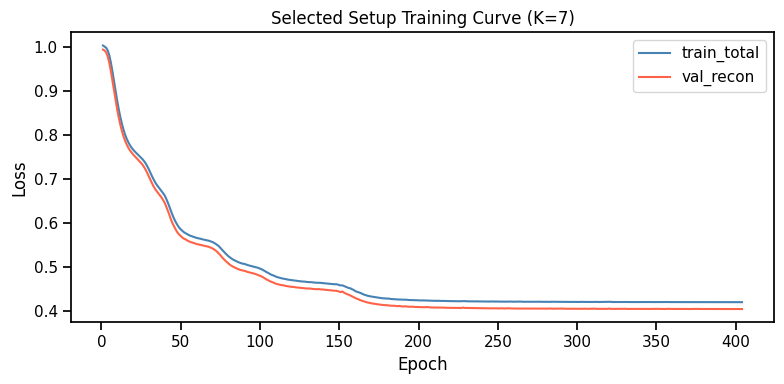

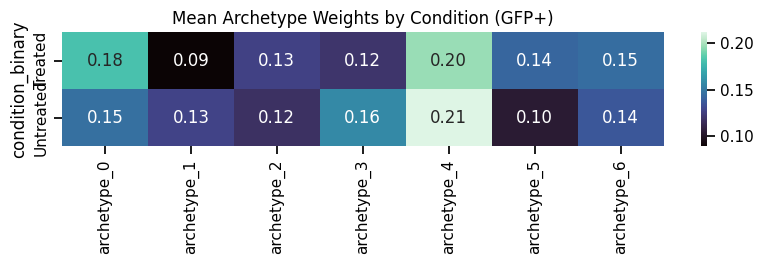

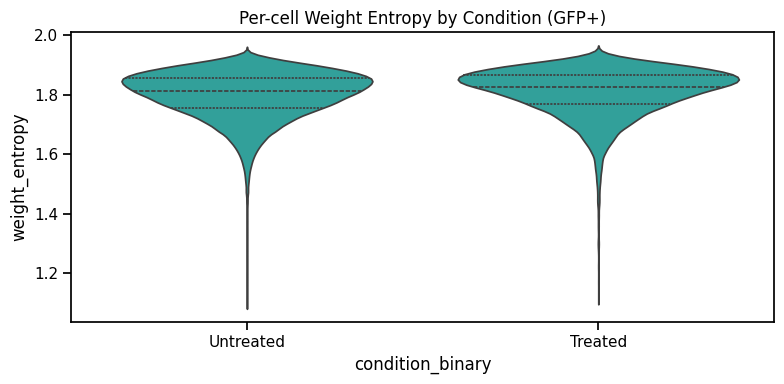

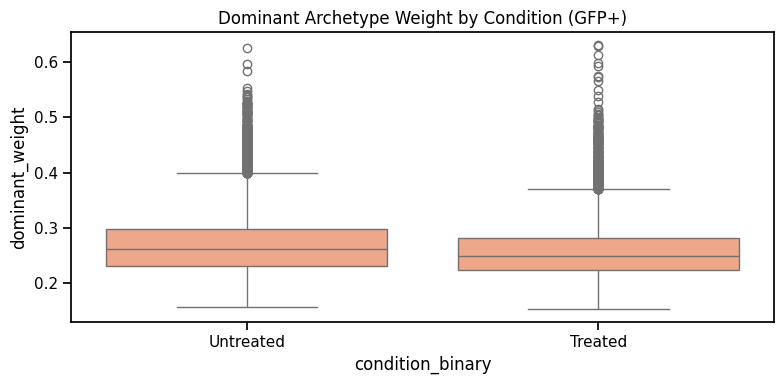

Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/condition_entropy_welch_tests.csv


,group1,group2,n1,n2,t_stat,p_value
0,Treated,Untreated,15919,55181,13.485721,2.638199e-41


In [10]:
# Reference-style plots: training curve, condition heatmap, entropy/dominance by condition
if len(history_df):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df['epoch'], history_df['loss'], label='train_total', color='steelblue')
    plt.plot(history_df['epoch'], history_df['val_recon'], label='val_recon', color='tomato')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Selected Setup Training Curve (K={W.shape[1]})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'selected_training_curve.png', dpi=150)
    plt.show()

heat_df = condition_means.set_index(condition_col)[component_cols]
plt.figure(figsize=(1.2 * len(component_cols), max(2.8, 0.8 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='mako')
plt.title('Mean Archetype Weights by Condition (GFP+)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'condition_mean_archetype_weights.png', dpi=150)
plt.show()

if weights_df[condition_col].nunique(dropna=False) > 1:
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=weights_df, x=condition_col, y='weight_entropy', inner='quartile', color='lightseagreen')
    plt.title('Per-cell Weight Entropy by Condition (GFP+)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'weight_entropy_by_condition.png', dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=weights_df, x=condition_col, y='dominant_weight', color='lightsalmon')
    plt.title('Dominant Archetype Weight by Condition (GFP+)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'dominant_weight_by_condition.png', dpi=150)
    plt.show()

# Welch t-test for entropy between condition groups (if scipy exists)
try:
    from itertools import combinations
    from scipy.stats import ttest_ind

    rows = []
    for g1, g2 in combinations(sorted(weights_df[condition_col].dropna().unique().tolist()), 2):
        x1 = weights_df.loc[weights_df[condition_col] == g1, 'weight_entropy'].dropna()
        x2 = weights_df.loc[weights_df[condition_col] == g2, 'weight_entropy'].dropna()
        stat, p = ttest_ind(x1, x2, equal_var=False)
        rows.append({'group1': g1, 'group2': g2, 'n1': len(x1), 'n2': len(x2), 't_stat': float(stat), 'p_value': float(p)})
    entropy_test_df = pd.DataFrame(rows)
except Exception as exc:
    entropy_test_df = pd.DataFrame(columns=['group1', 'group2', 'n1', 'n2', 't_stat', 'p_value'])
    print(f'Skipping Welch t-test (scipy unavailable): {exc}')

entropy_test_path = ANALYSIS_OUTDIR / 'condition_entropy_welch_tests.csv'
entropy_test_df.to_csv(entropy_test_path, index=False)
print(f'Saved: {entropy_test_path}')
if len(entropy_test_df):
    display(entropy_test_df)


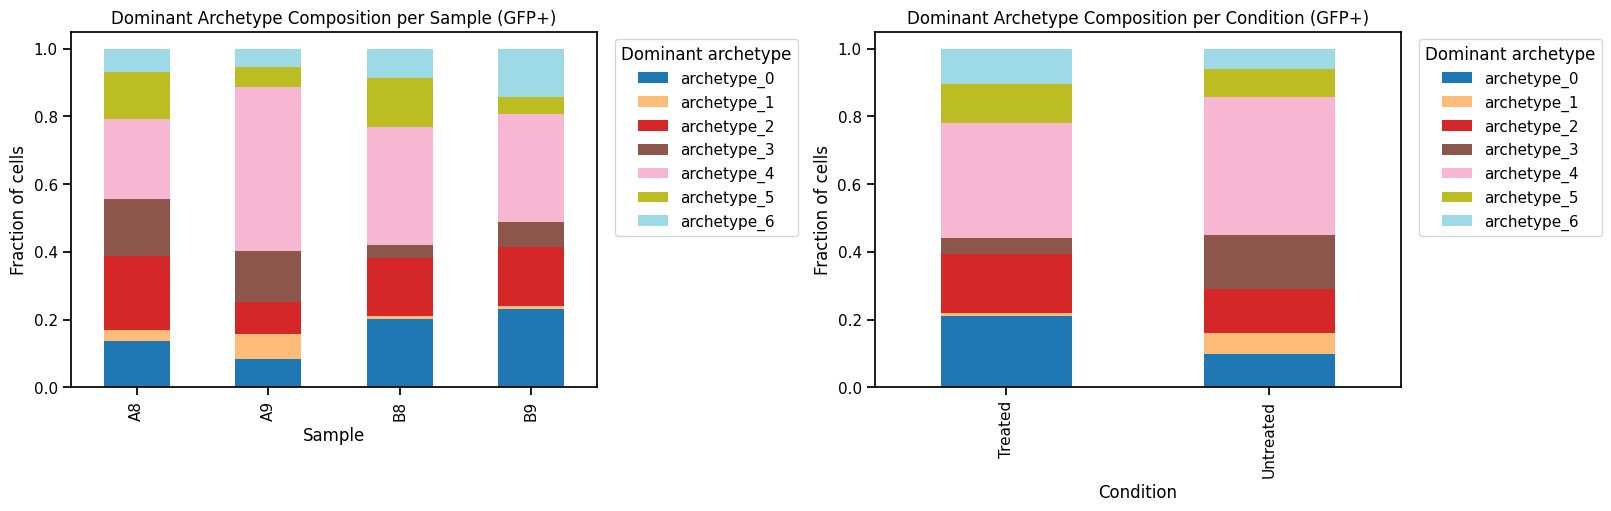

Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/dominant_archetype_treated_minus_untreated.csv


,archetype,treated_minus_untreated
0,archetype_0,0.110892
6,archetype_6,0.044825
2,archetype_2,0.040809
5,archetype_5,0.034371
1,archetype_1,-0.050870
4,archetype_4,-0.070787
3,archetype_3,-0.109240


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/dominant_archetype_per_sample_counts.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/dominant_archetype_per_sample_fraction.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/dominant_archetype_per_condition_counts.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/dominant_archetype_per_condition_fraction.csv


In [11]:
# Dominant archetype composition per sample and per condition
sample_col = ANALYSIS_CFG['sample_col']
condition_col = ANALYSIS_CFG['condition_binary_col']

if sample_col not in weights_df.columns:
    raise ValueError(f'Missing {sample_col} in weights_df; metadata merge failed.')

dom_sample_counts = (
    weights_df
    .groupby([sample_col, 'dominant_component_label'], as_index=False)
    .size()
    .rename(columns={'size': 'n_cells'})
)
dom_sample_frac = dom_sample_counts.copy()
dom_sample_frac['fraction'] = dom_sample_frac['n_cells'] / dom_sample_frac.groupby(sample_col)['n_cells'].transform('sum')

dom_condition_counts = (
    weights_df
    .groupby([condition_col, 'dominant_component_label'], as_index=False)
    .size()
    .rename(columns={'size': 'n_cells'})
)
dom_condition_frac = dom_condition_counts.copy()
dom_condition_frac['fraction'] = dom_condition_frac['n_cells'] / dom_condition_frac.groupby(condition_col)['n_cells'].transform('sum')

sample_counts_csv = ANALYSIS_OUTDIR / 'dominant_archetype_per_sample_counts.csv'
sample_frac_csv = ANALYSIS_OUTDIR / 'dominant_archetype_per_sample_fraction.csv'
cond_counts_csv = ANALYSIS_OUTDIR / 'dominant_archetype_per_condition_counts.csv'
cond_frac_csv = ANALYSIS_OUTDIR / 'dominant_archetype_per_condition_fraction.csv'

dom_sample_counts.to_csv(sample_counts_csv, index=False)
dom_sample_frac.to_csv(sample_frac_csv, index=False)
dom_condition_counts.to_csv(cond_counts_csv, index=False)
dom_condition_frac.to_csv(cond_frac_csv, index=False)

sample_plot = dom_sample_frac.pivot(index=sample_col, columns='dominant_component_label', values='fraction').fillna(0.0).sort_index()
condition_plot = dom_condition_frac.pivot(index=condition_col, columns='dominant_component_label', values='fraction').fillna(0.0).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sample_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Dominant Archetype Composition per Sample (GFP+)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Fraction of cells')
axes[0].legend(title='Dominant archetype', bbox_to_anchor=(1.02, 1), loc='upper left')

condition_plot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Dominant Archetype Composition per Condition (GFP+)')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Fraction of cells')
axes[1].legend(title='Dominant archetype', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig(FIG_DIR / 'dominant_archetype_stackedbars_sample_condition.png', dpi=150)
plt.show()

# Treated minus Untreated fraction delta per archetype
if {'Treated', 'Untreated'}.issubset(set(condition_plot.index.astype(str))):
    delta = (condition_plot.loc['Treated'] - condition_plot.loc['Untreated']).rename('treated_minus_untreated').reset_index()
    delta = delta.rename(columns={'dominant_component_label': 'archetype'})
    delta_csv = ANALYSIS_OUTDIR / 'dominant_archetype_treated_minus_untreated.csv'
    delta.to_csv(delta_csv, index=False)
    print(f'Saved: {delta_csv}')
    display(delta.sort_values('treated_minus_untreated', ascending=False))

print(f'Saved: {sample_counts_csv}')
print(f'Saved: {sample_frac_csv}')
print(f'Saved: {cond_counts_csv}')
print(f'Saved: {cond_frac_csv}')


In [12]:
# Reconstruction diagnostics table by condition and sample
mse_per_cell = np.mean((X - X_hat) ** 2, axis=1)
mae_per_cell = np.mean(np.abs(X - X_hat), axis=1)

recon_diag_df = pd.DataFrame({'cell_id': cell_ids, 'mse': mse_per_cell, 'mae': mae_per_cell})
meta_join = aligned_meta.copy()
meta_join['cell_id'] = meta_join.index.astype(str)
join_cols = ['cell_id'] + [c for c in [ANALYSIS_CFG['sample_col'], ANALYSIS_CFG['condition_binary_col']] if c in meta_join.columns]
recon_diag_df = recon_diag_df.merge(meta_join[join_cols], on='cell_id', how='left')

condition_col = ANALYSIS_CFG['condition_binary_col']
sample_col = ANALYSIS_CFG['sample_col']

recon_by_condition = (
    recon_diag_df
    .groupby(condition_col, as_index=False)
    .agg(mse_mean=('mse', 'mean'), mse_std=('mse', 'std'), mae_mean=('mae', 'mean'), mae_std=('mae', 'std'), n_cells=('cell_id', 'size'))
)
recon_by_sample = (
    recon_diag_df
    .groupby(sample_col, as_index=False)
    .agg(mse_mean=('mse', 'mean'), mse_std=('mse', 'std'), mae_mean=('mae', 'mean'), mae_std=('mae', 'std'), n_cells=('cell_id', 'size'))
)

recon_diag_csv = ANALYSIS_OUTDIR / 'reconstruction_diagnostics_per_cell.csv'
recon_condition_csv = ANALYSIS_OUTDIR / 'reconstruction_summary_by_condition.csv'
recon_sample_csv = ANALYSIS_OUTDIR / 'reconstruction_summary_by_sample.csv'
recon_diag_df.to_csv(recon_diag_csv, index=False)
recon_by_condition.to_csv(recon_condition_csv, index=False)
recon_by_sample.to_csv(recon_sample_csv, index=False)

print(f'Saved: {recon_diag_csv}')
print(f'Saved: {recon_condition_csv}')
print(f'Saved: {recon_sample_csv}')
display(recon_by_condition)
display(recon_by_sample.head(20))


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/reconstruction_diagnostics_per_cell.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/reconstruction_summary_by_condition.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/reconstruction_summary_by_sample.csv


,condition_binary,mse_mean,mse_std,mae_mean,mae_std,n_cells
0,Treated,0.422378,0.417294,0.474504,0.123536,15919
1,Untreated,0.400142,0.484134,0.460428,0.121885,55181


,sample_name,mse_mean,mse_std,mae_mean,mae_std,n_cells
0,A8,0.409232,0.339185,0.472910,0.119417,16454
1,A9,0.396280,0.533895,0.455125,0.122536,38727
2,B8,0.392073,0.379417,0.462880,0.114507,11084
3,B9,0.491850,0.486234,0.501152,0.138463,4835


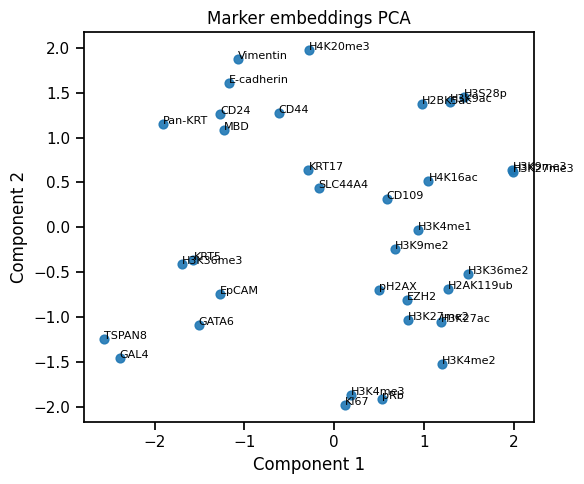

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


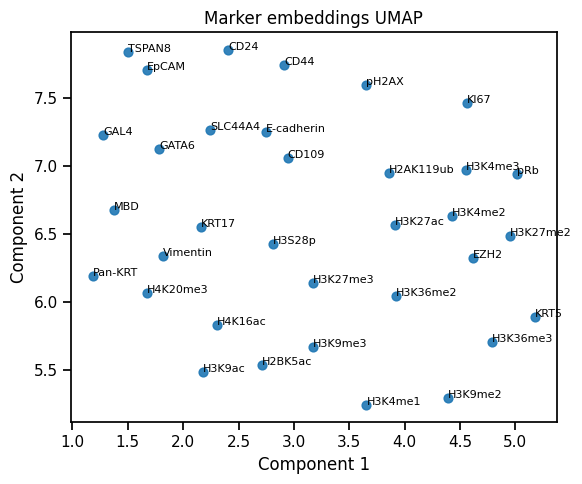

Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/marker_embedding_umap_coords.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/marker_embedding_cosine_similarity.csv


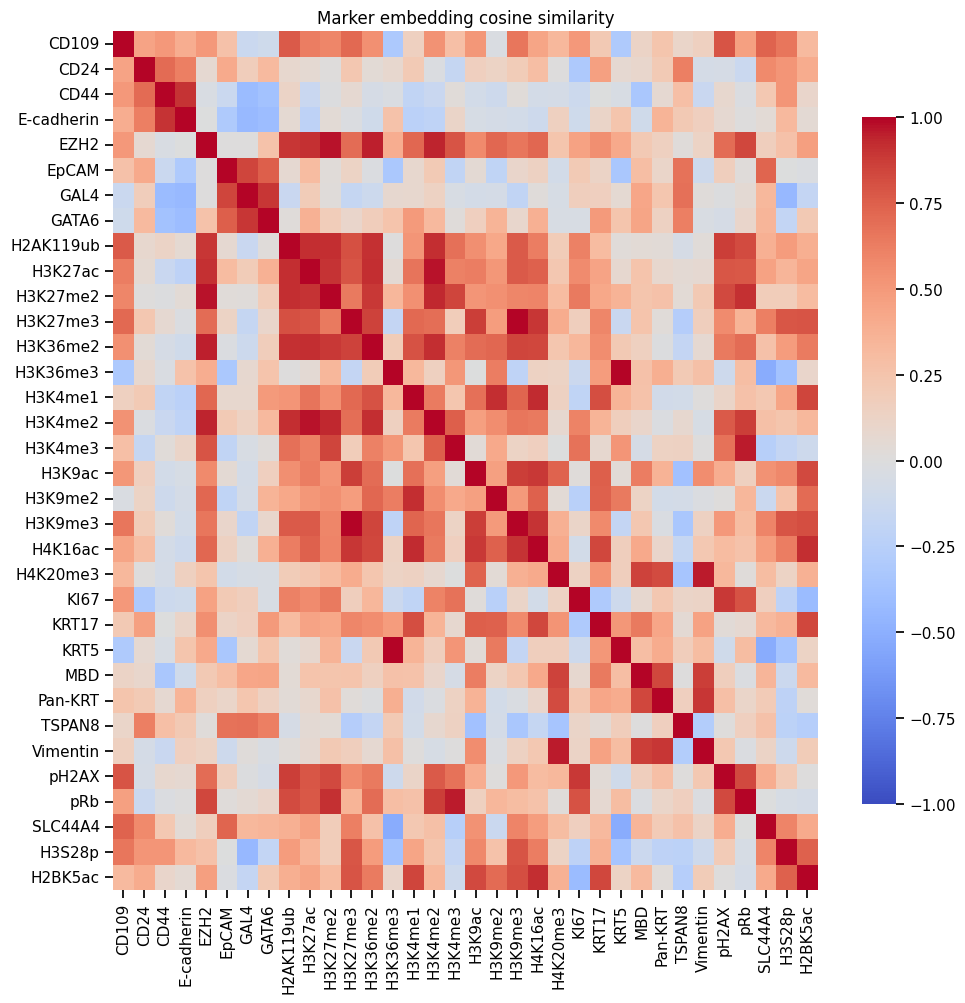

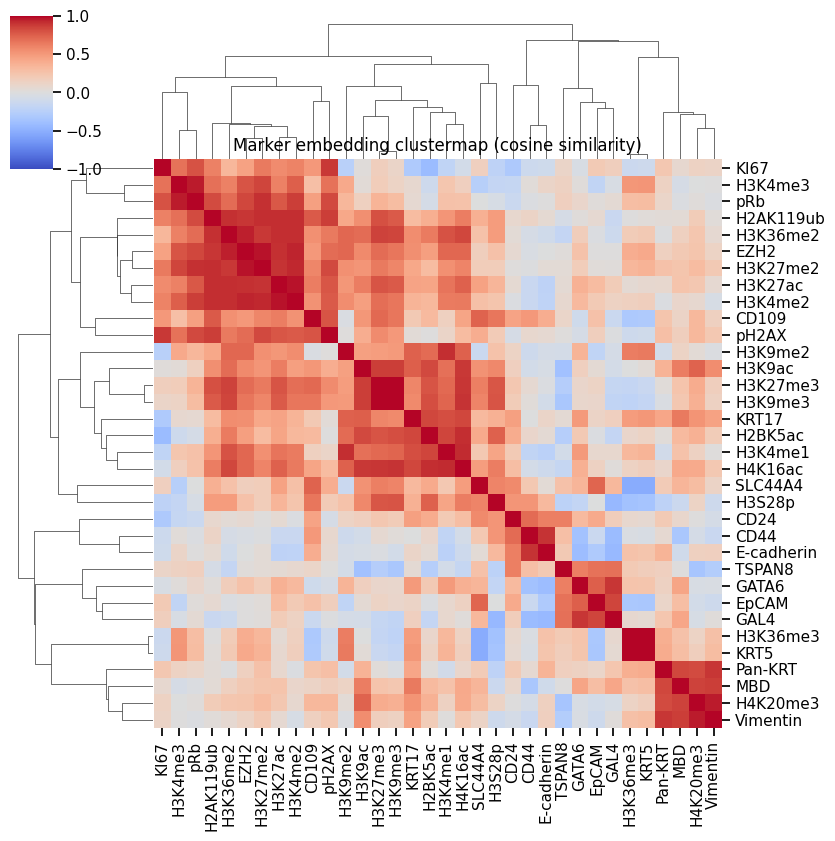

Saved marker nearest-neighbor table to: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/marker_embedding_neighbors.csv


,query,rank,neighbor,similarity
0,CD109,1,pH2AX,0.791215
1,CD109,2,H2AK119ub,0.770434
2,CD109,3,SLC44A4,0.740130
3,CD109,4,H3K27me3,0.716056
4,CD109,5,H3K9me3,0.663351
5,CD109,6,H3S28p,0.662069
6,CD109,7,H3K27ac,0.630707
7,CD109,8,H3K27me2,0.587655
8,CD24,1,CD44,0.710433
9,CD24,2,E-cadherin,0.622523


In [13]:
# Marker embedding analysis (E): PCA/UMAP + cosine neighbors (style aligned with CyEmbed/02_archetype_embedding_analysis.ipynb)
E = run.get('E')
if E is None:
    print('This run uses direct decoder; marker embedding matrix E is unavailable.')
else:
    E_pca = pca_projection(E, n_components=2)
    plot_embedding_scatter(E_pca, labels=marker_names, title='Marker embeddings PCA')
    plt.savefig(FIG_DIR / 'marker_embeddings_pca.png', dpi=150)
    plt.show()

    E_umap = umap_projection(E, n_neighbors=min(10, max(2, E.shape[0] - 1)), min_dist=0.1, random_state=7)
    if E_umap is not None:
        plot_embedding_scatter(E_umap, labels=marker_names, title='Marker embeddings UMAP')
        plt.savefig(FIG_DIR / 'marker_embeddings_umap.png', dpi=150)
        plt.show()

        marker_umap_df = pd.DataFrame(E_umap, columns=['umap1', 'umap2'])
        marker_umap_df.insert(0, 'marker', marker_names)
        marker_umap_path = ANALYSIS_OUTDIR / 'marker_embedding_umap_coords.csv'
        marker_umap_df.to_csv(marker_umap_path, index=False)
        print(f'Saved: {marker_umap_path}')
    else:
        print('umap-learn not installed; skipping marker embedding UMAP.')

    marker_sim = cosine_similarity_matrix(E)
    marker_sim_path = ANALYSIS_OUTDIR / 'marker_embedding_cosine_similarity.csv'
    pd.DataFrame(marker_sim, index=marker_names, columns=marker_names).to_csv(marker_sim_path)
    print(f'Saved: {marker_sim_path}')

    plot_matrix_heatmap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title='Marker embedding cosine similarity',
        cmap='coolwarm',
        figsize=(max(8, len(marker_names) * 0.3), max(6, len(marker_names) * 0.3)),
        vmin=-1,
        vmax=1,
    )
    plt.savefig(FIG_DIR / 'marker_embedding_cosine_similarity_heatmap.png', dpi=150)
    plt.show()

    plot_clustermap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title='Marker embedding clustermap (cosine similarity)',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        figsize=(max(7, len(marker_names) * 0.25), max(7, len(marker_names) * 0.25)),
        metric='euclidean',
        method='average',
    )

    nn_df = nearest_neighbors_from_similarity(marker_sim, marker_names, k=min(8, max(1, len(marker_names) - 1)))
    nn_path = ANALYSIS_OUTDIR / 'marker_embedding_neighbors.csv'
    nn_df.to_csv(nn_path, index=False)
    print(f'Saved marker nearest-neighbor table to: {nn_path}')
    display(nn_df.head(40))


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/archetype_treated_minus_untreated.csv


,archetype,treated_mean,untreated_mean,treated_minus_untreated,abs_difference,welch_t_stat,welch_p_value
0,archetype_5,0.141989,0.104243,0.037746,0.037746,75.358166,0.000000e+00
1,archetype_0,0.180871,0.145706,0.035165,0.035165,-88.438988,0.000000e+00
2,archetype_6,0.145022,0.135848,0.009174,0.009174,10.676256,1.510841e-26
3,archetype_2,0.126547,0.117670,0.008877,0.008877,-71.016935,0.000000e+00
4,archetype_4,0.196305,0.211568,-0.015263,0.015263,-23.124748,2.635439e-117
5,archetype_3,0.120018,0.157062,-0.037044,0.037044,66.424259,0.000000e+00
6,archetype_1,0.089248,0.127902,-0.038654,0.038654,16.566057,2.648454e-61


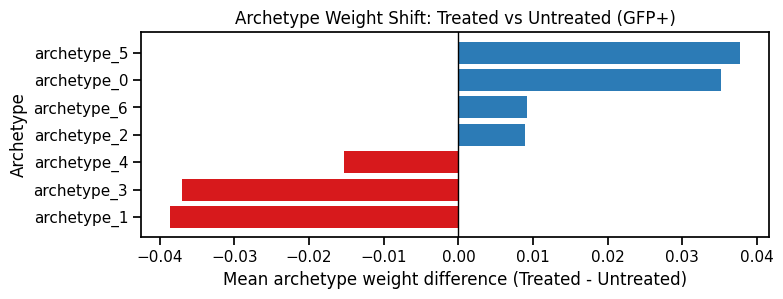

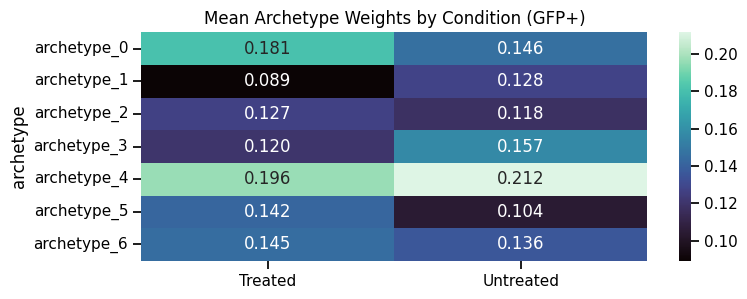

In [14]:
# Archetype-difference plots between Treated and Untreated (requested)
condition_col = ANALYSIS_CFG['condition_binary_col']
component_cols = [c for c in weights_df.columns if c.startswith('archetype_')]

if condition_col not in weights_df.columns:
    raise ValueError(f"Missing condition column '{condition_col}' in weights_df.")

cond_values = set(weights_df[condition_col].dropna().astype(str).unique().tolist())
if not {'Treated', 'Untreated'}.issubset(cond_values):
    print(f"Skipping treated-vs-untreated archetype difference: available conditions = {sorted(cond_values)}")
else:
    treated_mean = weights_df.loc[weights_df[condition_col] == 'Treated', component_cols].mean(axis=0)
    untreated_mean = weights_df.loc[weights_df[condition_col] == 'Untreated', component_cols].mean(axis=0)
    diff = treated_mean - untreated_mean

    diff_df = pd.DataFrame({
        'archetype': component_cols,
        'treated_mean': treated_mean.values,
        'untreated_mean': untreated_mean.values,
        'treated_minus_untreated': diff.values,
        'abs_difference': np.abs(diff.values),
    }).sort_values('treated_minus_untreated', ascending=False).reset_index(drop=True)

    # Optional per-archetype Welch t-test across cells
    try:
        from scipy.stats import ttest_ind
        pvals = []
        tstats = []
        for comp in component_cols:
            x1 = weights_df.loc[weights_df[condition_col] == 'Treated', comp].dropna()
            x2 = weights_df.loc[weights_df[condition_col] == 'Untreated', comp].dropna()
            t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
            tstats.append(float(t_stat))
            pvals.append(float(p_val))
        diff_df['welch_t_stat'] = tstats
        diff_df['welch_p_value'] = pvals
    except Exception as exc:
        print(f'Welch t-test unavailable: {exc}')

    diff_csv = ANALYSIS_OUTDIR / 'archetype_treated_minus_untreated.csv'
    diff_df.to_csv(diff_csv, index=False)
    print(f'Saved: {diff_csv}')
    display(diff_df)

    # Bar plot of treated-untreated deltas
    plot_df = diff_df.sort_values('treated_minus_untreated', ascending=True)
    plt.figure(figsize=(8, max(3, 0.45 * len(plot_df))))
    colors = ['#2c7bb6' if v >= 0 else '#d7191c' for v in plot_df['treated_minus_untreated']]
    plt.barh(plot_df['archetype'], plot_df['treated_minus_untreated'], color=colors)
    plt.axvline(0.0, color='black', linewidth=1)
    plt.xlabel('Mean archetype weight difference (Treated - Untreated)')
    plt.ylabel('Archetype')
    plt.title('Archetype Weight Shift: Treated vs Untreated (GFP+)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'archetype_treated_minus_untreated_barh.png', dpi=150)
    plt.show()

    # Side-by-side condition means for each archetype
    cond_means = pd.DataFrame({
        'archetype': component_cols,
        'Treated': treated_mean.values,
        'Untreated': untreated_mean.values,
    }).set_index('archetype')
    plt.figure(figsize=(8, max(3, 0.45 * len(cond_means))))
    sns.heatmap(cond_means, annot=True, fmt='.3f', cmap='mako')
    plt.title('Mean Archetype Weights by Condition (GFP+)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'archetype_condition_means_heatmap.png', dpi=150)
    plt.show()


## Notes

- This notebook now mirrors the GFP+ reference analysis style with condition/sample dominance and entropy summaries.
- Added explicit Treated-vs-Untreated archetype-difference plots and tables.
- Added marker-embedding PCA/UMAP + cosine-neighbor analysis (matching style from `CyEmbed/02_archetype_embedding_analysis.ipynb`).
- Override the selected run with `override_run_dir`, `override_run_id`, or `override_rank_index`.
- Figures are saved under `outputs/batch4_unt_tr_6dosages_gfppos_only_analysis/figures/`.
